#                                                    **Mini_Projet IA (ML)**

##                **-   Prediction d'un AVC:**

## **I-   DATA Understinding (Import Bibio )**

      - Pandas

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

###   2        -    Chargement des données

In [ ]:
dataset = pd.read_csv("C:\\Users\\sm720\\Desktop\\Mini_P\\Mini_P\\DATA\\healthcare-dataset-stroke-data.csv"

## 3-  Affichage des données

In [ ]:
print(dataset.head(10))

In [ ]:

---  ------             --------------  -----
 0   id                 5110 non-null   int64
 1   gender             5110 non-null   object
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64
 4   heart_disease      5110 non-null   int64
 5   ever_married       5110 non-null   object
 6   work_type          5110 non-null   object
 7   Residence_type     5110 non-null   object
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object
 11  stroke             5110 non-null   int64
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

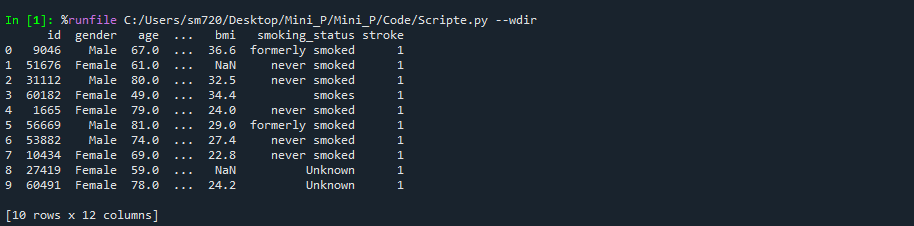

### 4-  hyotypose

In [ ]:
#volume : nombre total d'instances
#dimension : nombre total des attributs
print("(volume , dimension) =" ,dataset.shape)

In [ ]:
[10 rows x 12 columns]
(volume , dimension) = (5110, 12)
Nombre de lignes : 5110
Nombre de colonnes : 12

Out

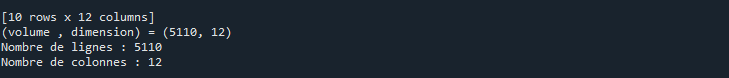

### 5  -    Afficher les colonnes

In [ ]:
cols = ["gender", "age", "bmi", "avg_glucose_level", "smoking_status", "stroke"]
subset = dataset[cols]
print(subset)

Out

In [ ]:
%runfile C:/Users/sm720/Desktop/Mini_P/Mini_P/Code/Scripte.py --wdir
      id  gender   age  ...   bmi   smoking_status stroke
0   9046    Male  67.0  ...  36.6  formerly smoked      1
1  51676  Female  61.0  ...   NaN     never smoked      1
2  31112    Male  80.0  ...  32.5     never smoked      1
3  60182  Female  49.0  ...  34.4           smokes      1
4   1665  Female  79.0  ...  24.0     never smoked      1
5  56669    Male  81.0  ...  29.0  formerly smoked      1
6  53882    Male  74.0  ...  27.4     never smoked      1
7  10434  Female  69.0  ...  22.8     never smoked      1
8  27419  Female  59.0  ...   NaN          Unknown      1
9  60491  Female  78.0  ...  24.2          Unknown      1

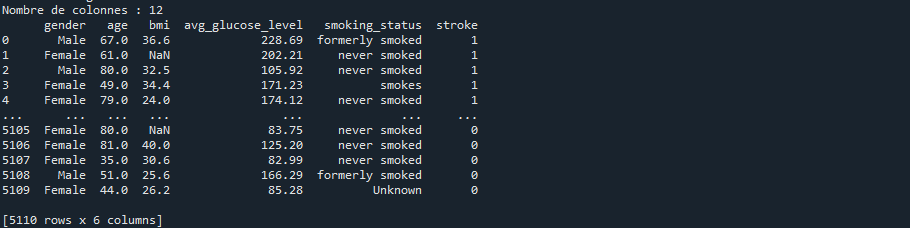

### 6   -  Observatuon sur les lignes dataset.info()

Statistiques descriptives


                                                            Note
genre female and male with smoking_status sont considérés des objets ,          donc il faut les transformer en valeur numérique.

In [ ]:
print(dataset.dtypes)

print(dataset.info())
print(dataset.describe(include='all'))
print(dataset.columns)

Out

In [ ]:
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 5110 non-null   int64
 1   gender             5110 non-null   object
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64
 4   heart_disease      5110 non-null   int64
 5   ever_married       5110 non-null   object
 6   work_type          5110 non-null   object
 7   Residence_type     5110 non-null   object
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object
 11  stroke             5110 non-null   int64
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None
                  id  gender  ...  smoking_status       stroke
count    5110.000000    5110  ...            5110  5110.000000
unique           NaN       3  ...               4          NaN
top              NaN  Female  ...    never smoked          NaN
freq             NaN    2994  ...            1892          NaN
mean    36517.829354     NaN  ...             NaN     0.048728
std     21161.721625     NaN  ...             NaN     0.215320
min        67.000000     NaN  ...             NaN     0.000000
25%     17741.250000     NaN  ...             NaN     0.000000
50%     36932.000000     NaN  ...             NaN     0.000000
75%     54682.000000     NaN  ...             NaN     0.000000
max     72940.000000     NaN  ...             NaN     1.000000

[11 rows x 12 columns]
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')
stroke
0    4861
1     249
Name: count, dtype: int64
Text(0.5, 1.0, 'Distribution de stroke')
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

%runfile C:/Users/sm720/Desktop/Mini_P/Mini_P/Code/Scripte.py --wdir
      id  gender   age  ...   bmi   smoking_status stroke
0   9046    Male  67.0  ...  36.6  formerly smoked      1
1  51676  Female  61.0  ...   NaN     never smoked      1
2  31112    Male  80.0  ...  32.5     never smoked      1
3  60182  Female  49.0  ...  34.4           smokes      1
4   1665  Female  79.0  ...  24.0     never smoked      1
5  56669    Male  81.0  ...  29.0  formerly smoked      1
6  53882    Male  74.0  ...  27.4     never smoked      1
7  10434  Female  69.0  ...  22.8     never smoked      1
8  27419  Female  59.0  ...   NaN          Unknown      1
9  60491  Female  78.0  ...  24.2          Unknown      1

[10 rows x 12 columns]
(volume , dimension) = (5110, 12)
Nombre de lignes : 5110
Nombre de colonnes : 12
      gender   age   bmi  avg_glucose_level   smoking_status  stroke
0       Male  67.0  36.6             228.69  formerly smoked       1
1     Female  61.0   NaN             202.21     never smoked       1
2       Male  80.0  32.5             105.92     never smoked       1
3     Female  49.0  34.4             171.23           smokes       1
4     Female  79.0  24.0             174.12     never smoked       1
     ...   ...   ...                ...              ...     ...
5105  Female  80.0   NaN              83.75     never smoked       0
5106  Female  81.0  40.0             125.20     never smoked       0
5107  Female  35.0  30.6              82.99     never smoked       0
5108    Male  51.0  25.6             166.29  formerly smoked       0
5109  Female  44.0  26.2              85.28          Unknown       0

[5110 rows x 6 columns]



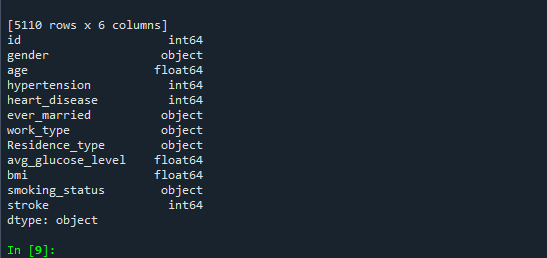

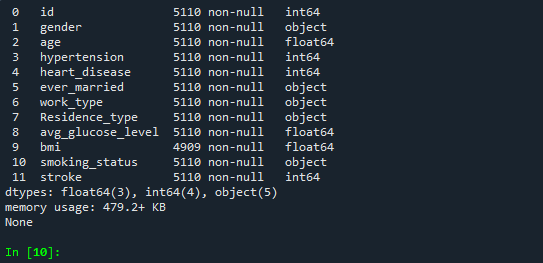

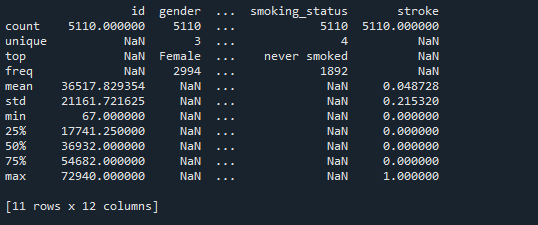

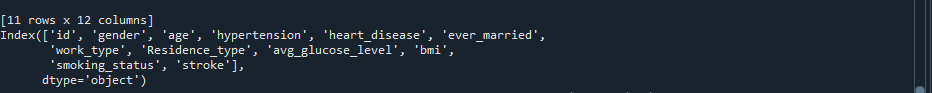

### 7-      Deleted  duble

In [ ]:
print(dataset.isnull().sum())
data = dataset.copy()
print("Nombre de doublons avant suppression: ", data.duplicated().sum())

Out

In [ ]:
dtype: int64
Nombre de doublons avant suppression:  0
heart_disease
0    4834
1     276
Name: count, dtype: int64

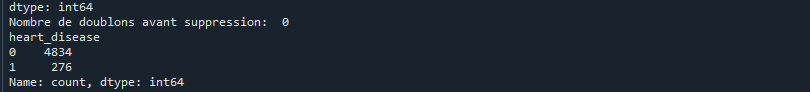

# ***II                   Visualisation***

-      Nettoyage de données

IN

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(dataset.isnull())
plt.show()

Problème des valeurs nulles
Toute la ligne dans une seule colonne

Out

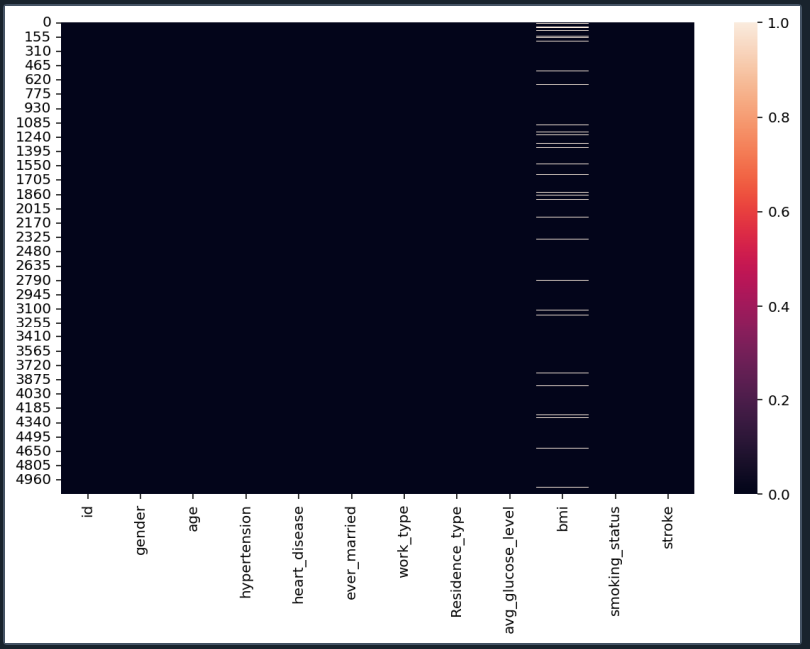

##               -            la distribution des classes dans la colonne cible

IN

In [ ]:
print(dataset["stroke"].value_counts())
dataset.stroke.value_counts(normalize=True).plot(kind='bar', alpha=1)
ret =plt.title('Distribution de stroke')
# Fixer les labels de l’axe x (“0” → “No”, “1” → “Yes”)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('stroke')
plt.ylabel('Proportion')
plt.show()

Out

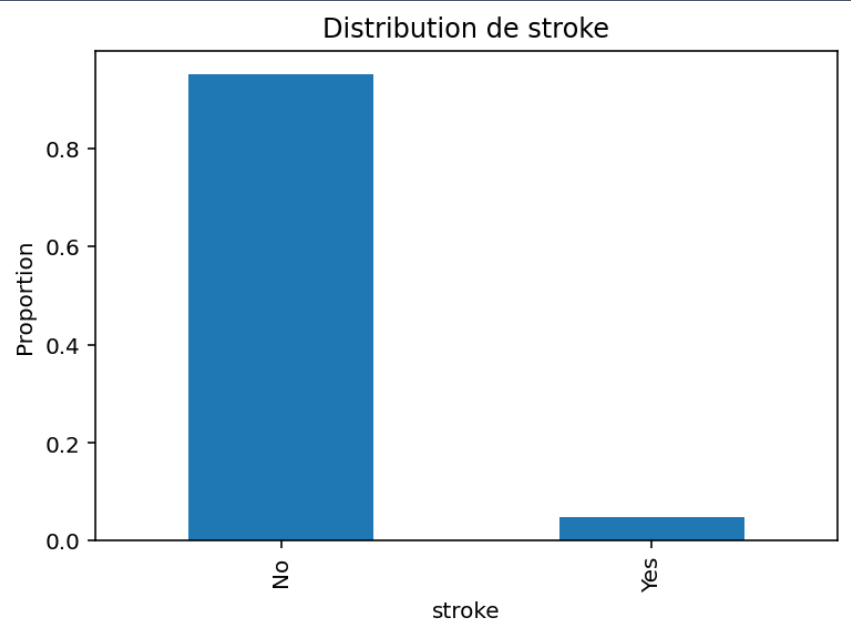

## - Histogrammes pour la colonne smoking_status,  définis par la colonne stroke
           la distribution de la consommation smoking

IN

In [ ]:
_ = dataset.hist(figsize=(20, 14), bins=30, column='smoking_status', by='stroke')
plt.show()
#trace des histogrammes de la variable colonne X dans le dataset.
_ = dataset.hist(figsize=(20, 14), bins=30,
                 column='hypertension',
                 by='stroke')
plt.show()
_ = dataset.hist(figsize=(20, 14),
                 bins=30,
                 column='Residence_type',
                 by='stroke')
plt.show()

Out

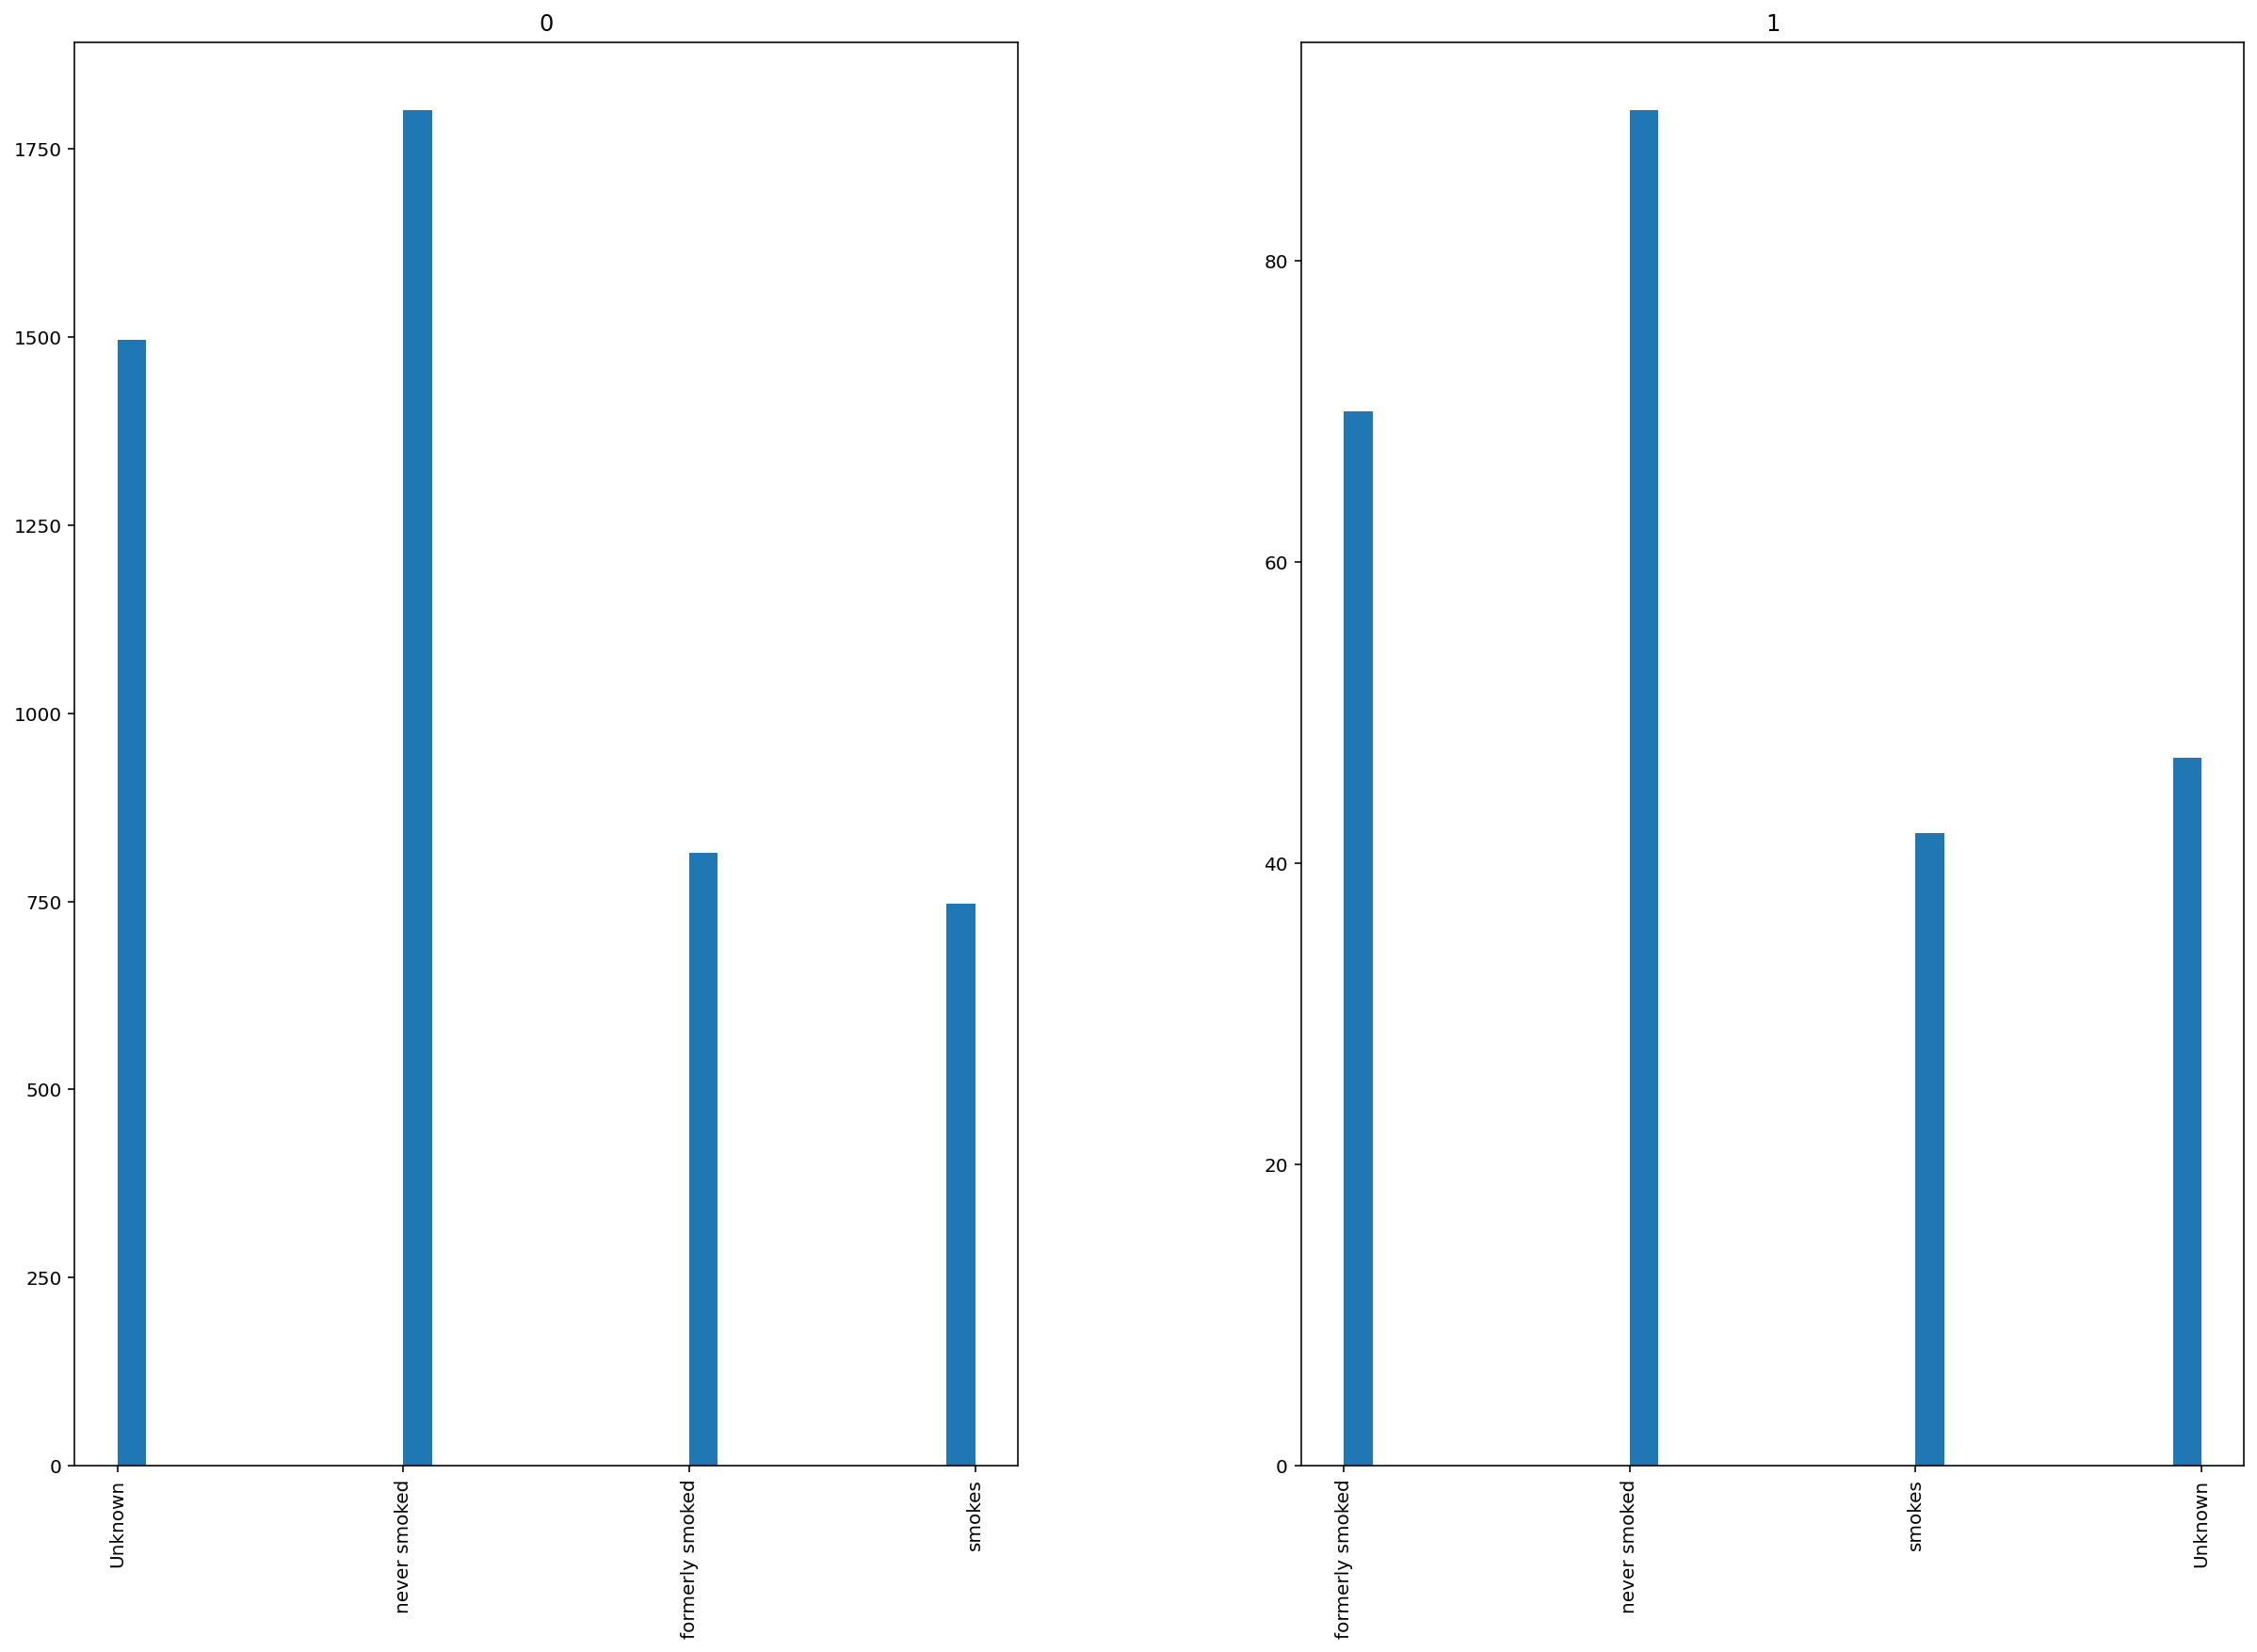

##    -visualisation  pour les colonnes Age and Hypertention, définis par la colonne stroke

           la distribution age & hypertention

in

In [ ]:
sns.countplot(x='stroke', hue="age", data = dataset)
plt.show()
sns.countplot(x='stroke', hue="hypertension", data = dataset)
plt.show()

Out

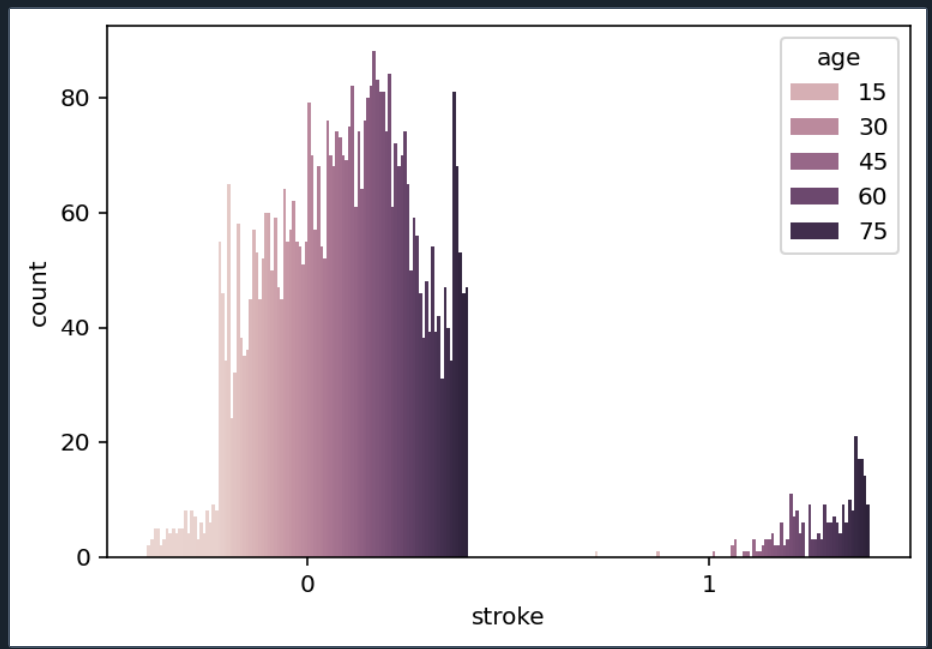

In [ ]:
sns.countplot(x='stroke', hue="age", data = dataset)
plt.show()
sns.countplot(x='stroke', hue="hypertension", data = dataset)
plt.show()

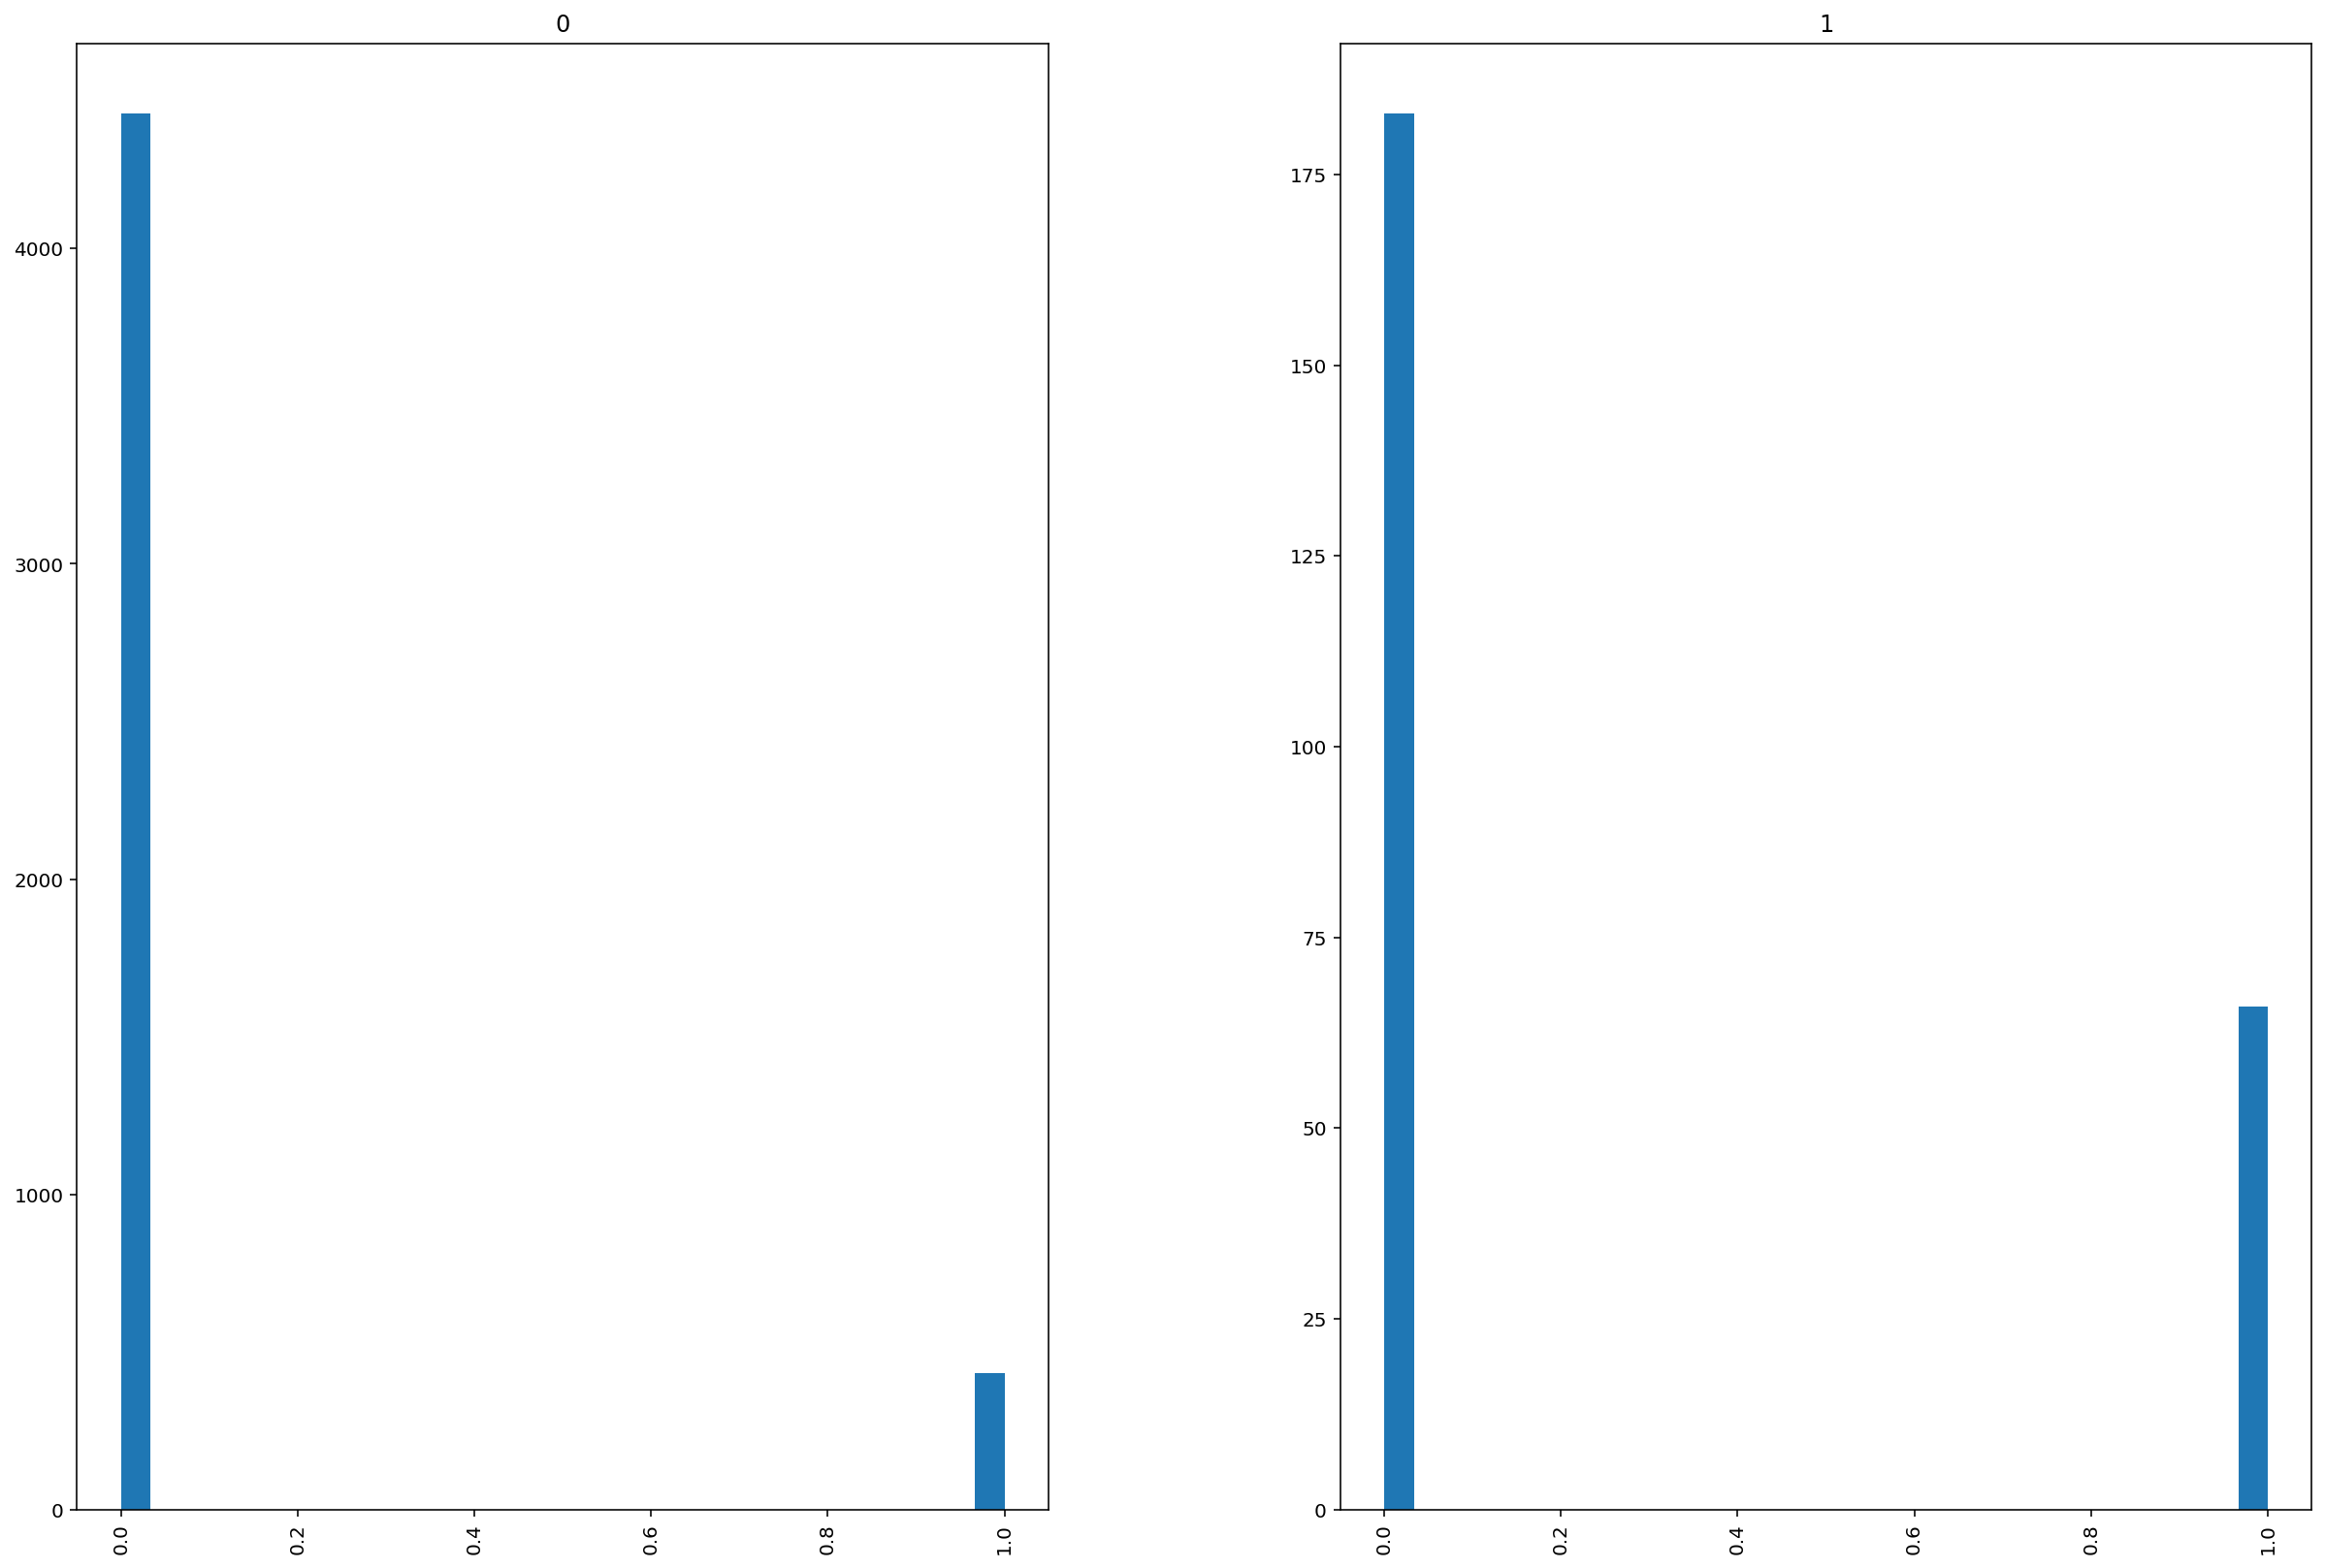

## -          la répartition des personnes selon leur habitation

IN

In [ ]:
sns.countplot(x =target_column , hue = 'Residence_type', data = dataset ,palette = "Set2")
plt.show()
sns.countplot(x =target_column , hue = 'age', data = dataset)
plt.show()
sns.countplot(x =target_column , hue ='smoking_status', data = dataset , palette='BuPu_r')
plt.show()

Out

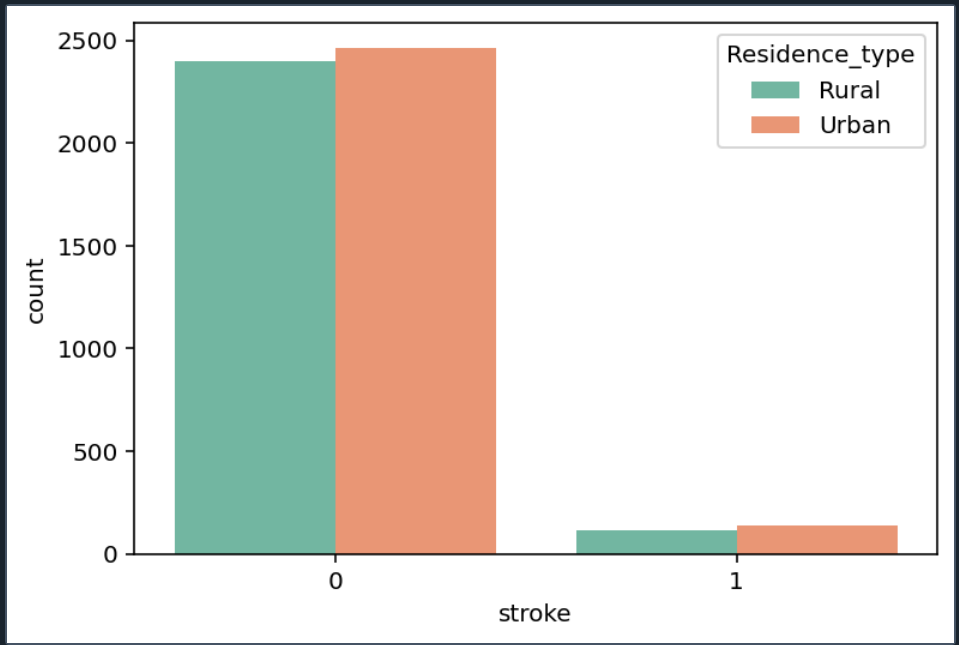

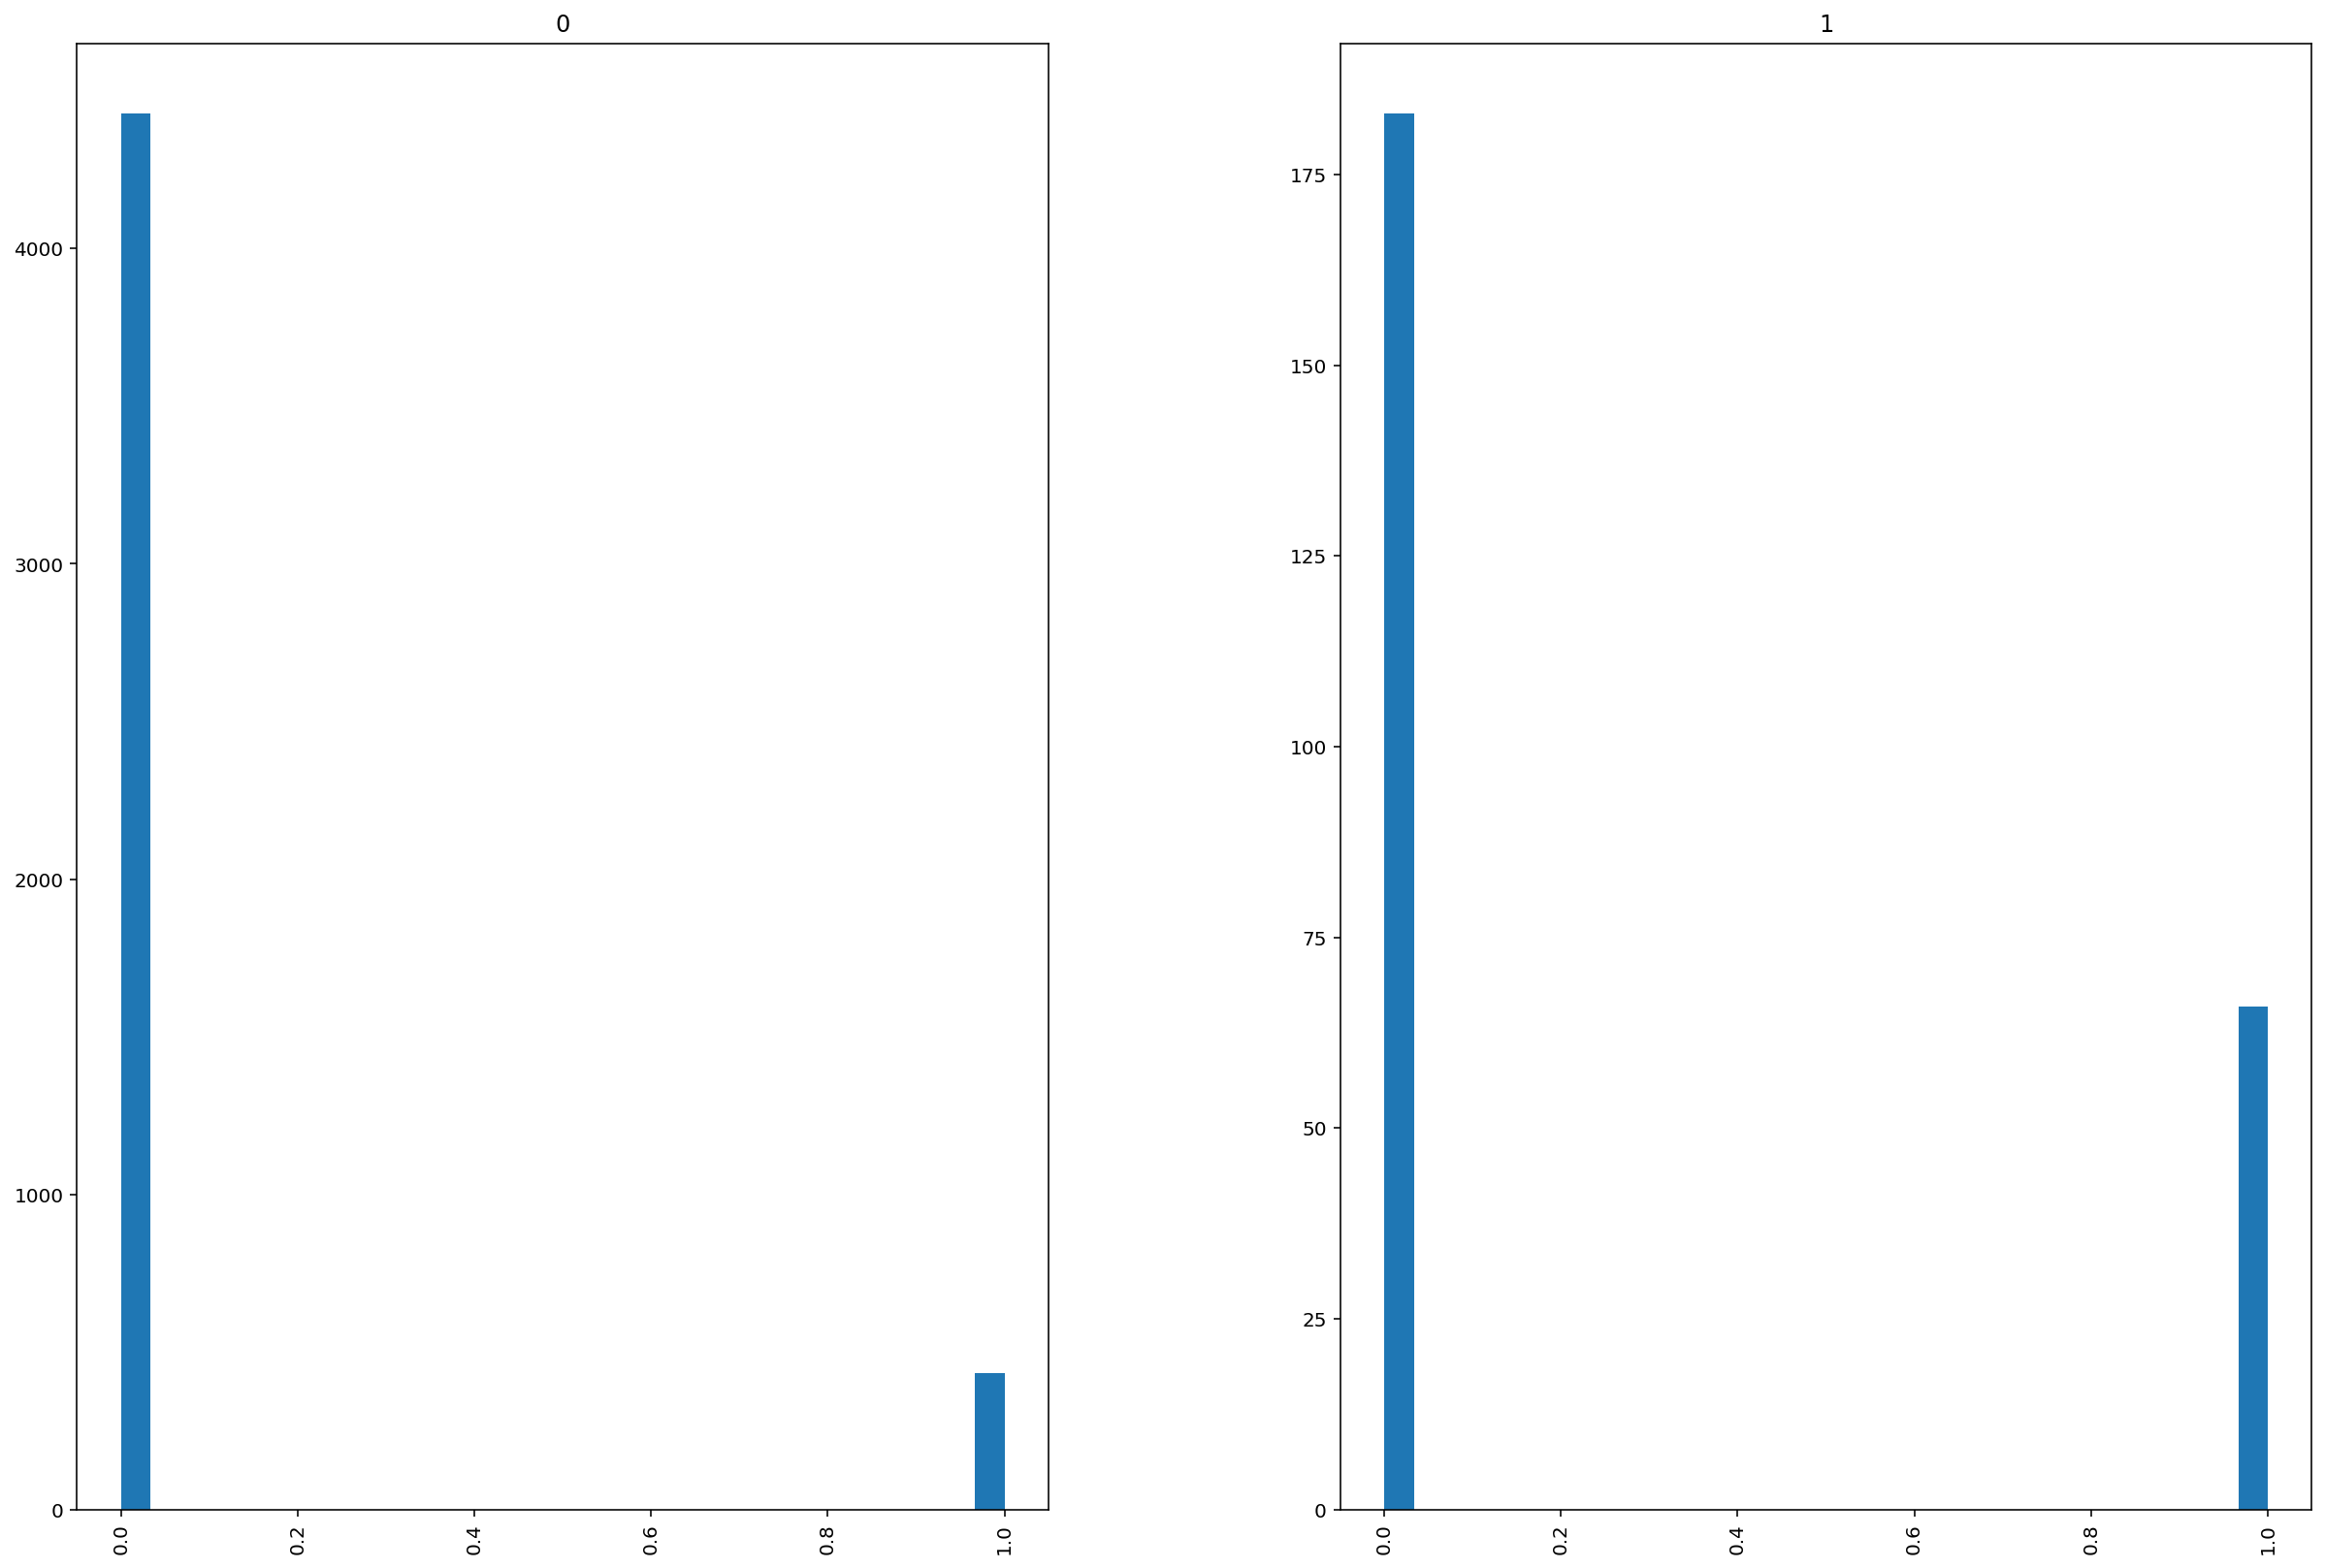

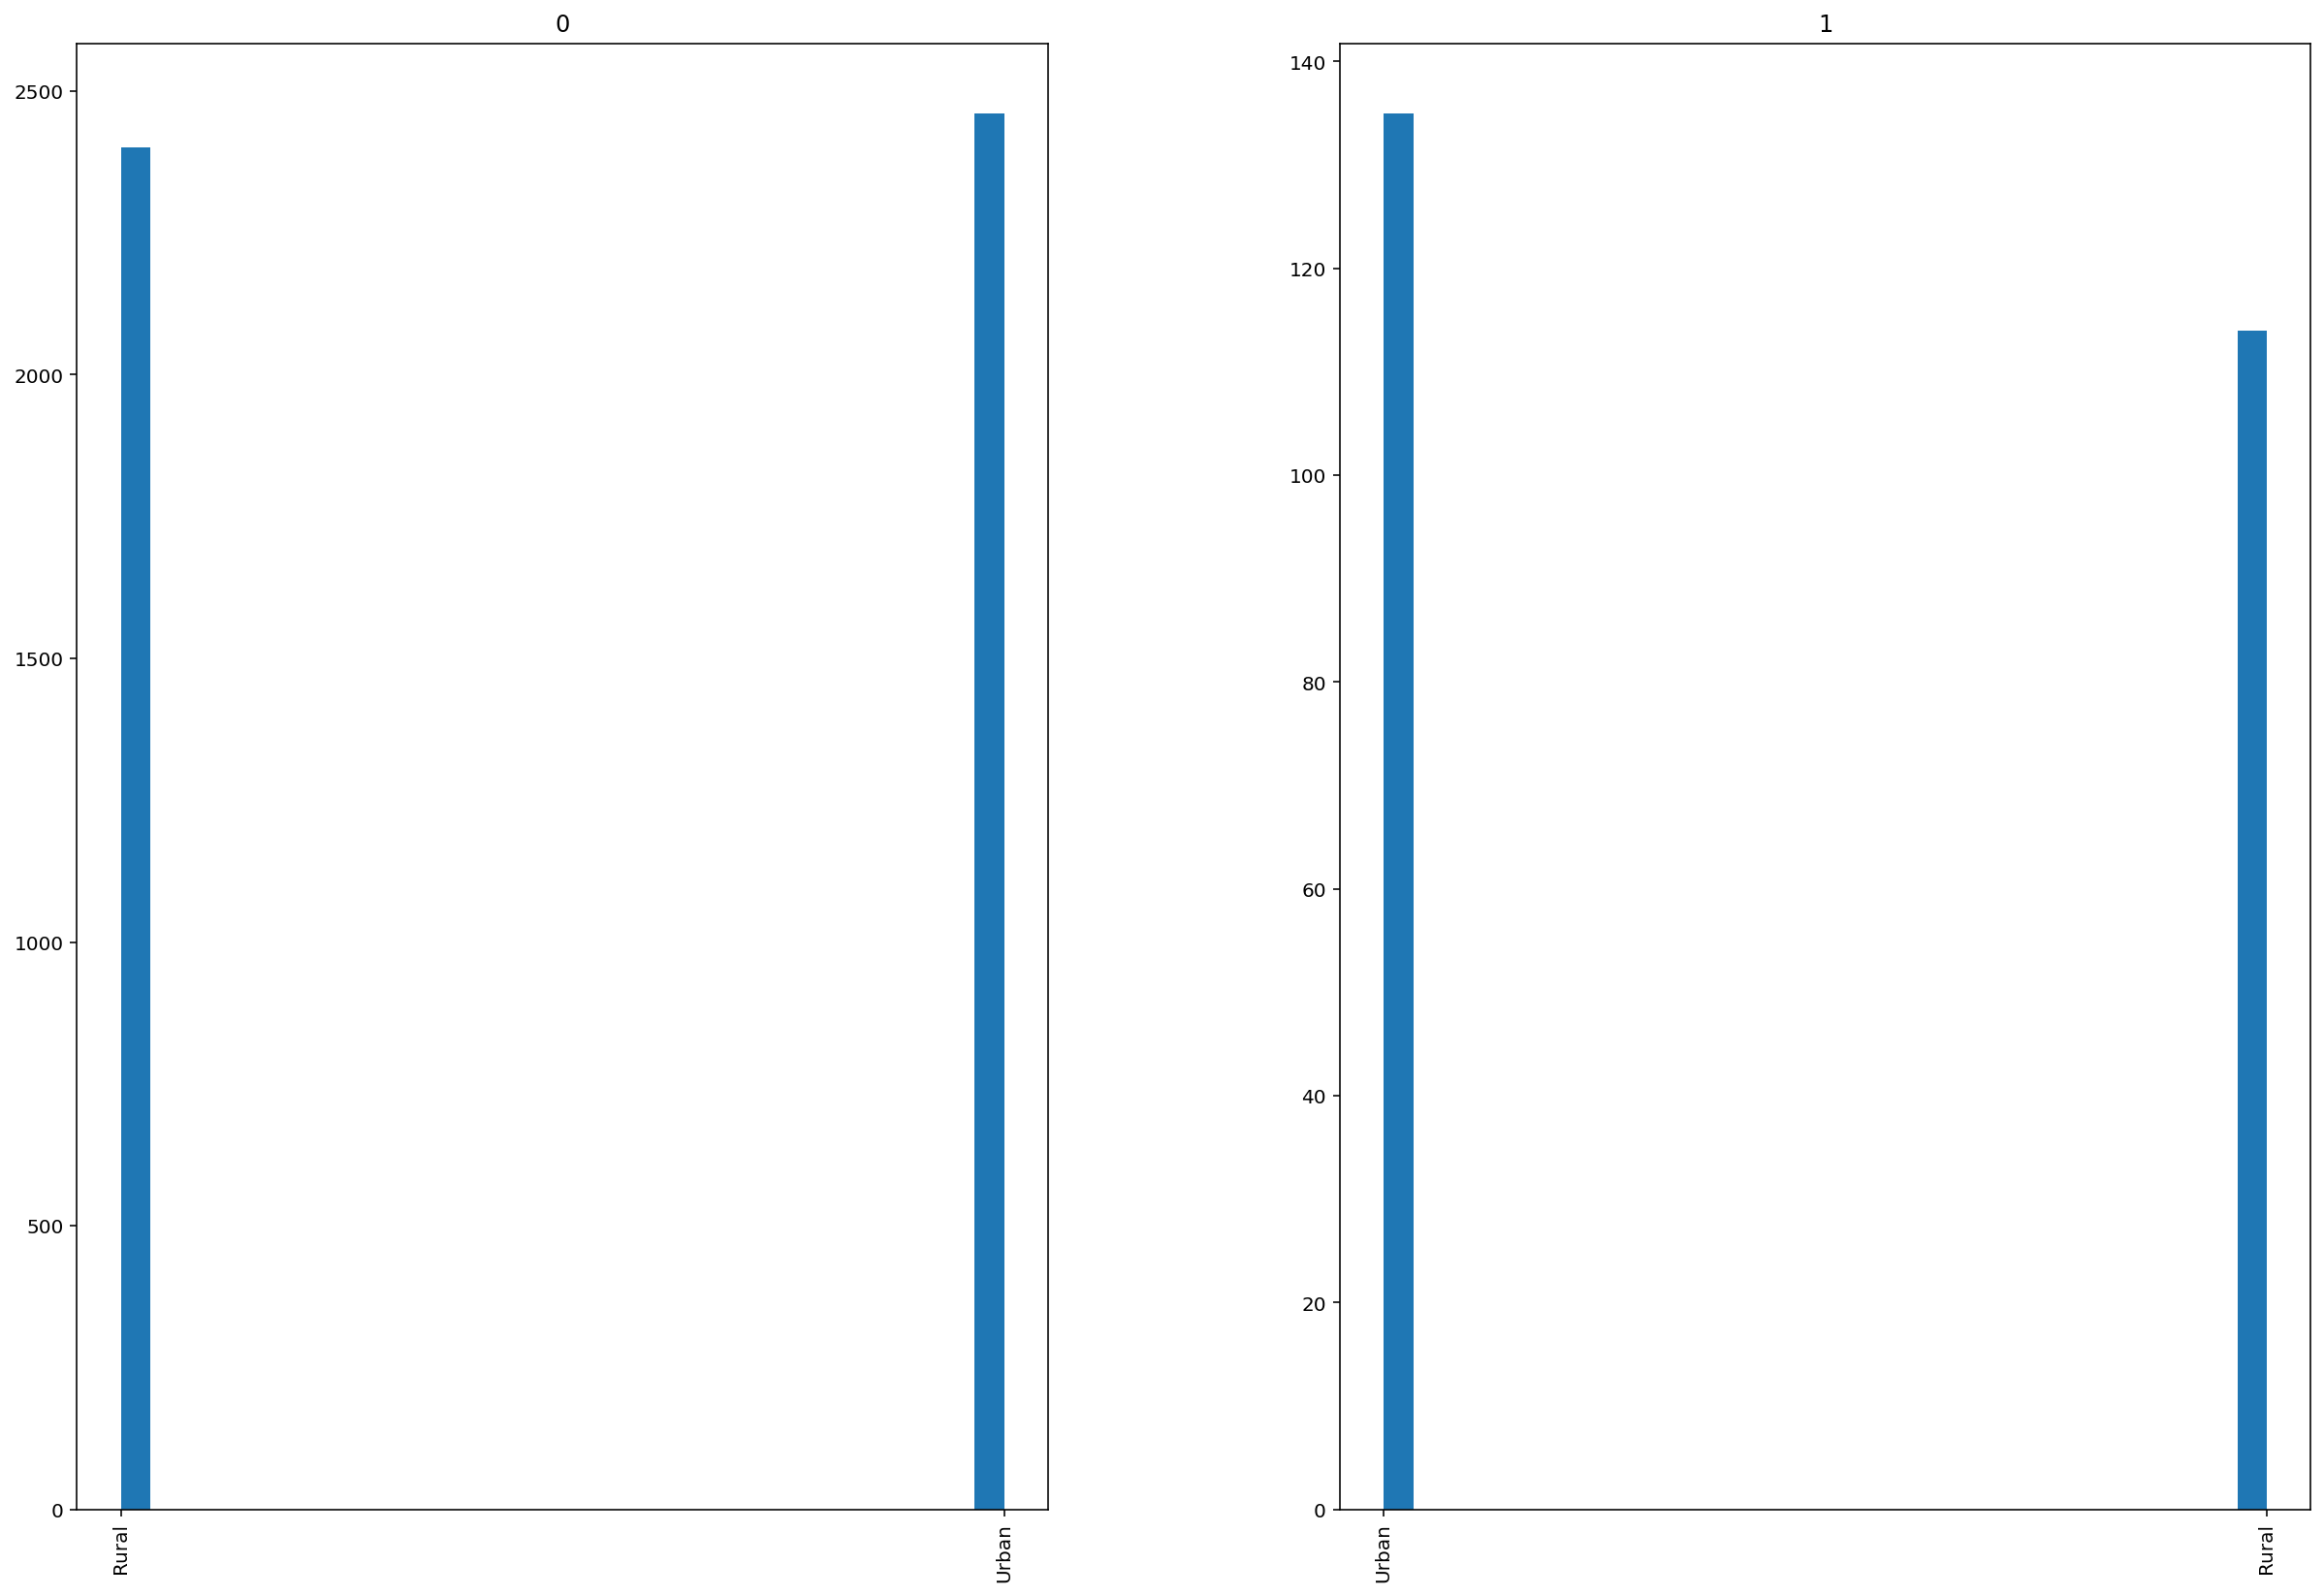

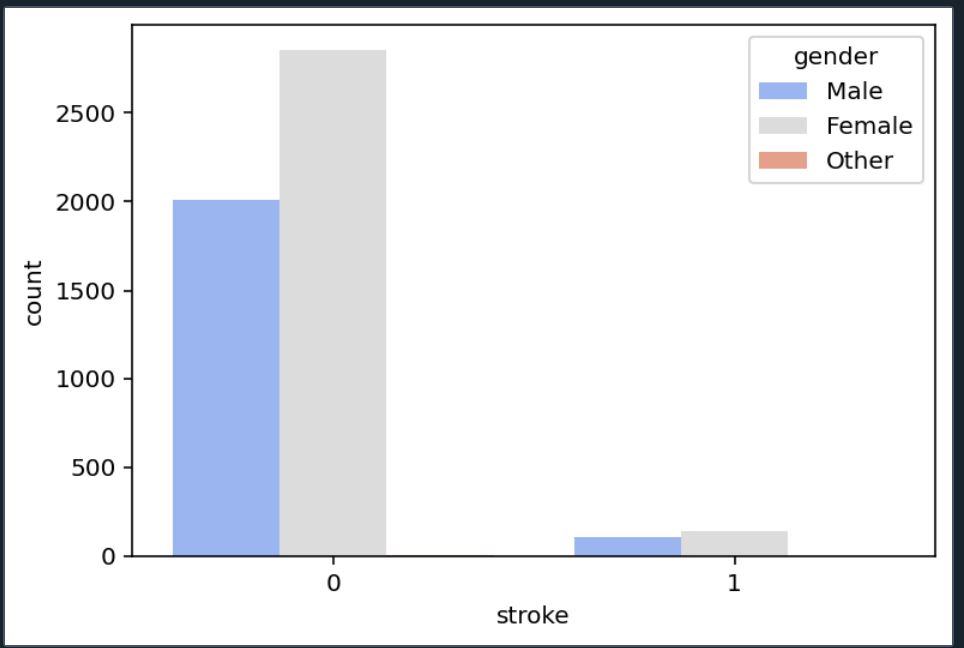

### -         Répartition des antécédents de tabagisme selon la présence de maladie cardiaque

In

In [ ]:
columns = ["hypertension" , "smoking_status" , "ever_married" , "work_type" ]
_ = sns.pairplot(
    data=dataset,
    vars=columns,
    hue=target_column,
    plot_kws={"alpha": 0.5},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30}
)
plt.show()

Out

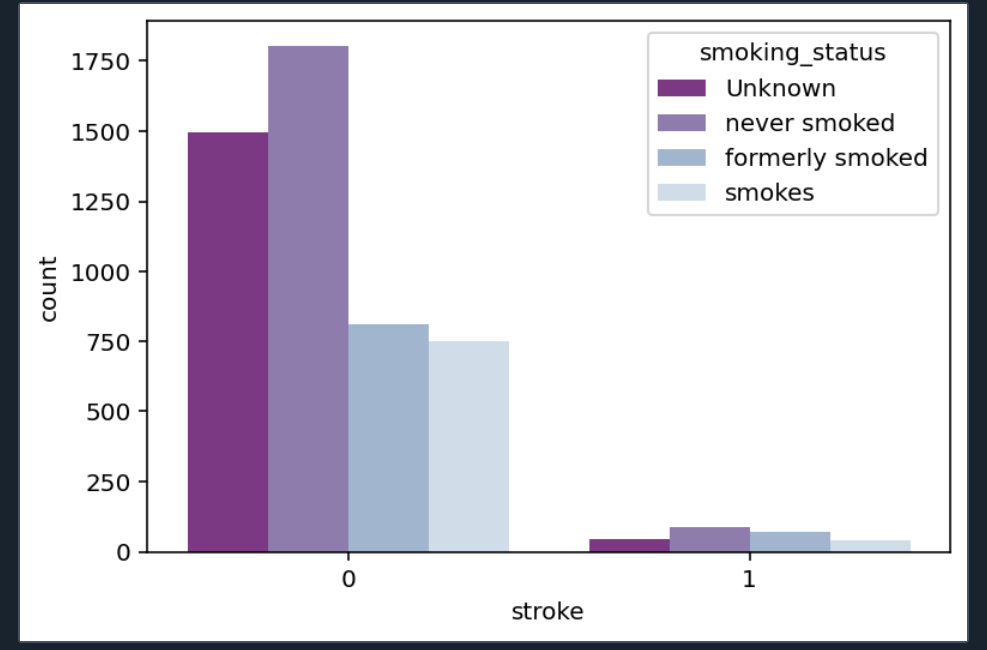

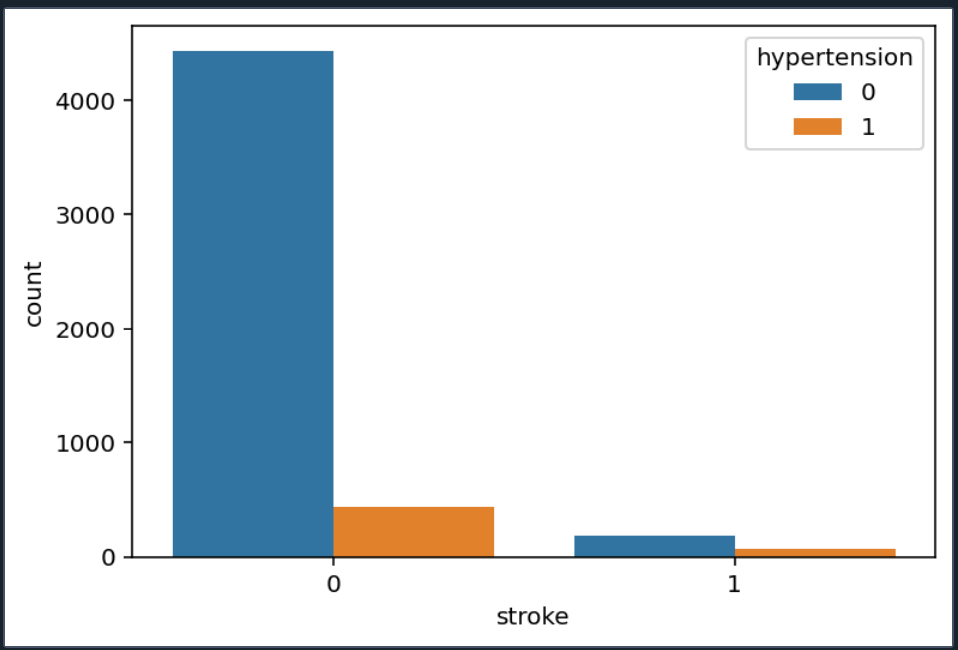

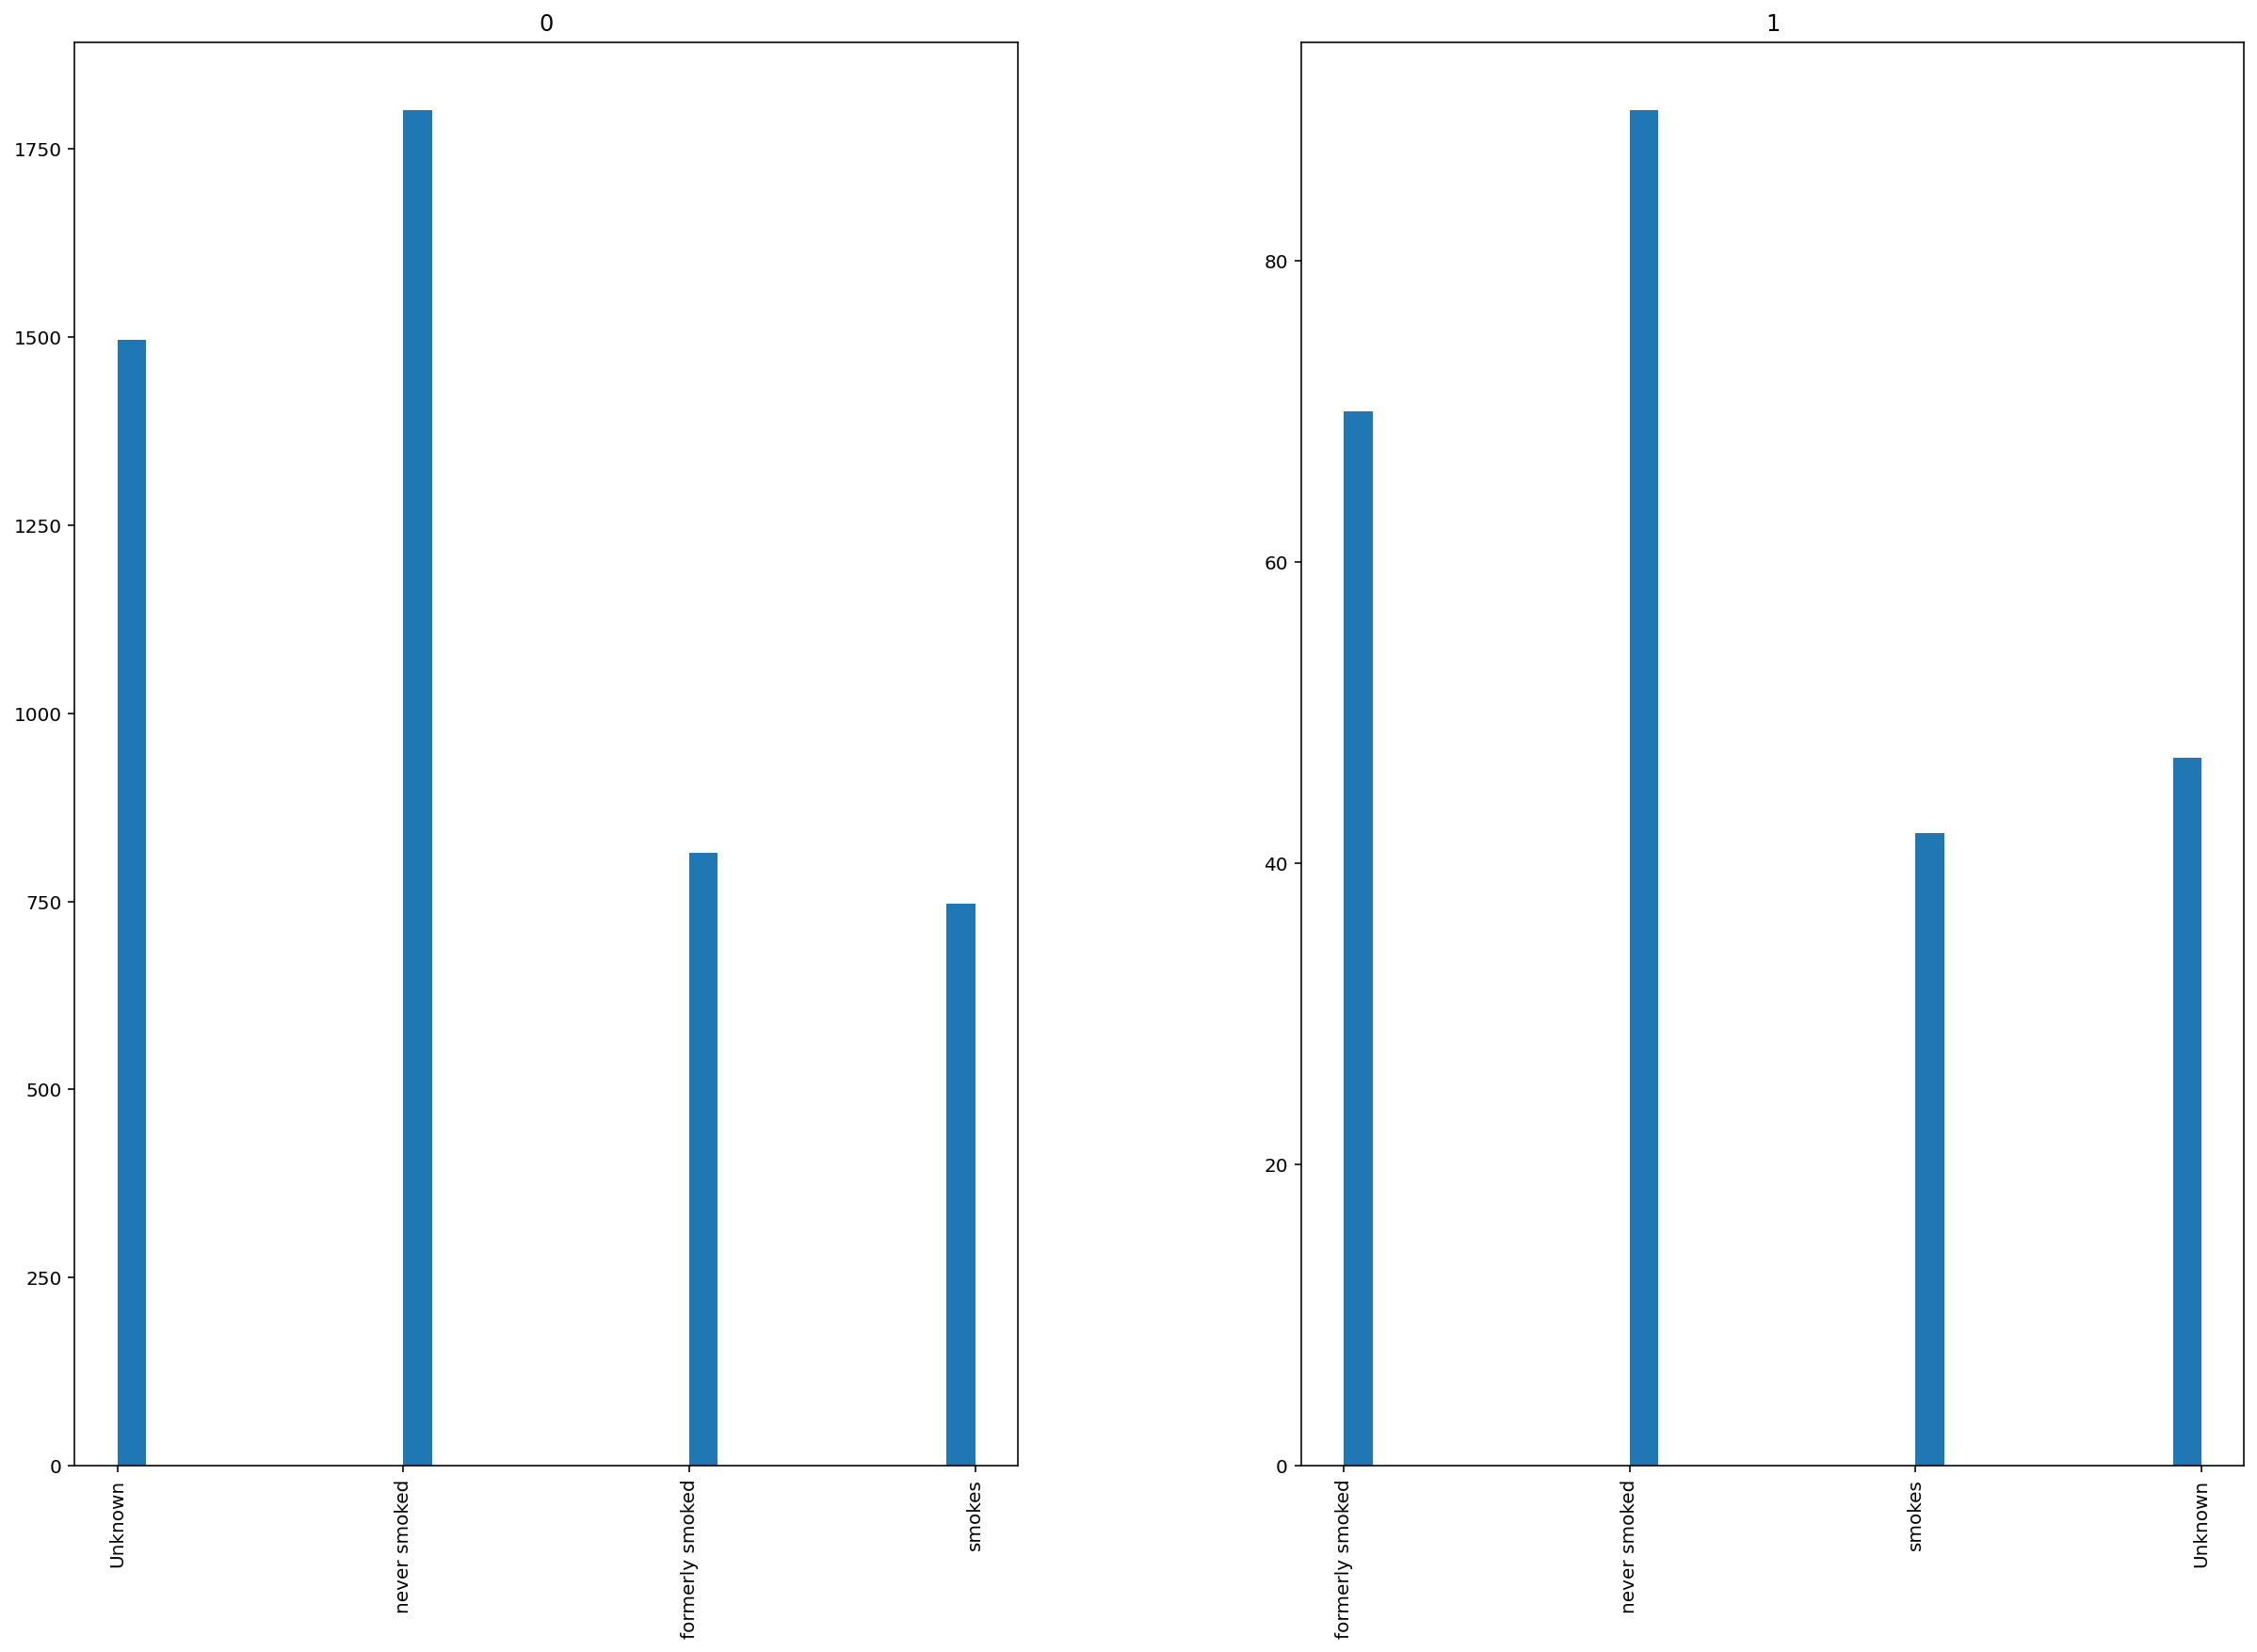

## -        Visualisation la corrélation entre la cible et les autres caractéristiques

IN

In [ ]:
numeric_df = df.select_dtypes(include=['number'])  # sélectionne les colonnes numériques
corr = numeric_df.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, fmt=".3f", linewidths=0.5)
plt.show()

Out

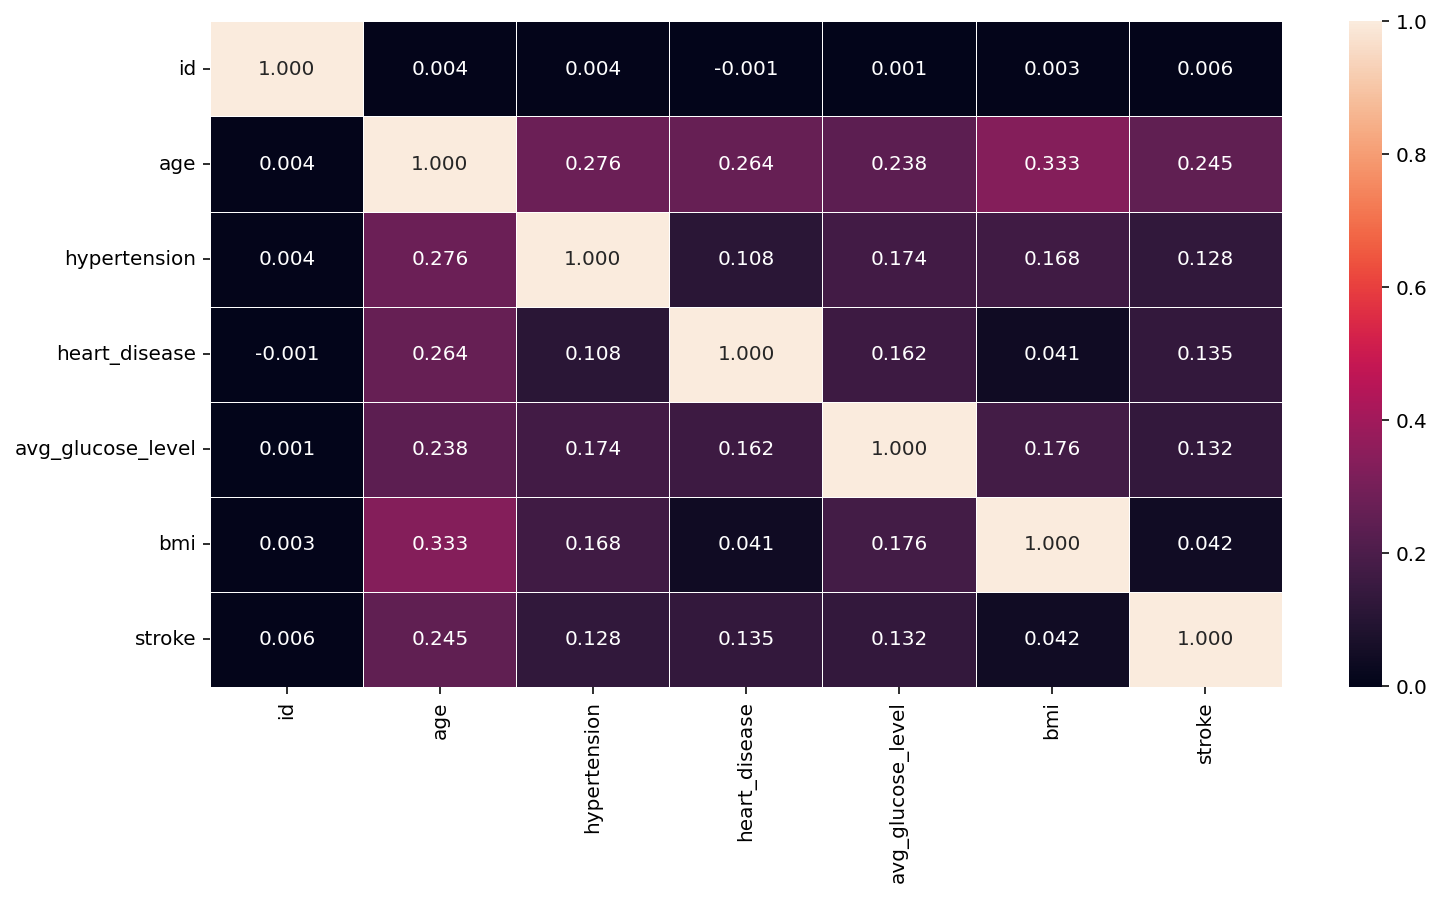

## -      Visualiser la distribution des variables quantitatives présentes dans le dataset (BOXPLOT)

IN



In [ ]:
plt.xticks(rotation=45, fontsize=12)
plt.title("Boxplot des variables quantitatives", fontsize=16)
plt.ylabel("Valeurs", fontsize=14)
plt.xlabel("Variables", fontsize=14)
# Ajout d'une grille pour une meilleure lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Personnalisation des axes
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()
def load_data(path="C:\\Users\\sm720\\Desktop\\Mini_P\\Mini_P\\DATA\\healthcare-dataset-stroke-data.csv",sep=',' ,low_memory=False):
    df = pd.read_csv(path)
    return df

Out

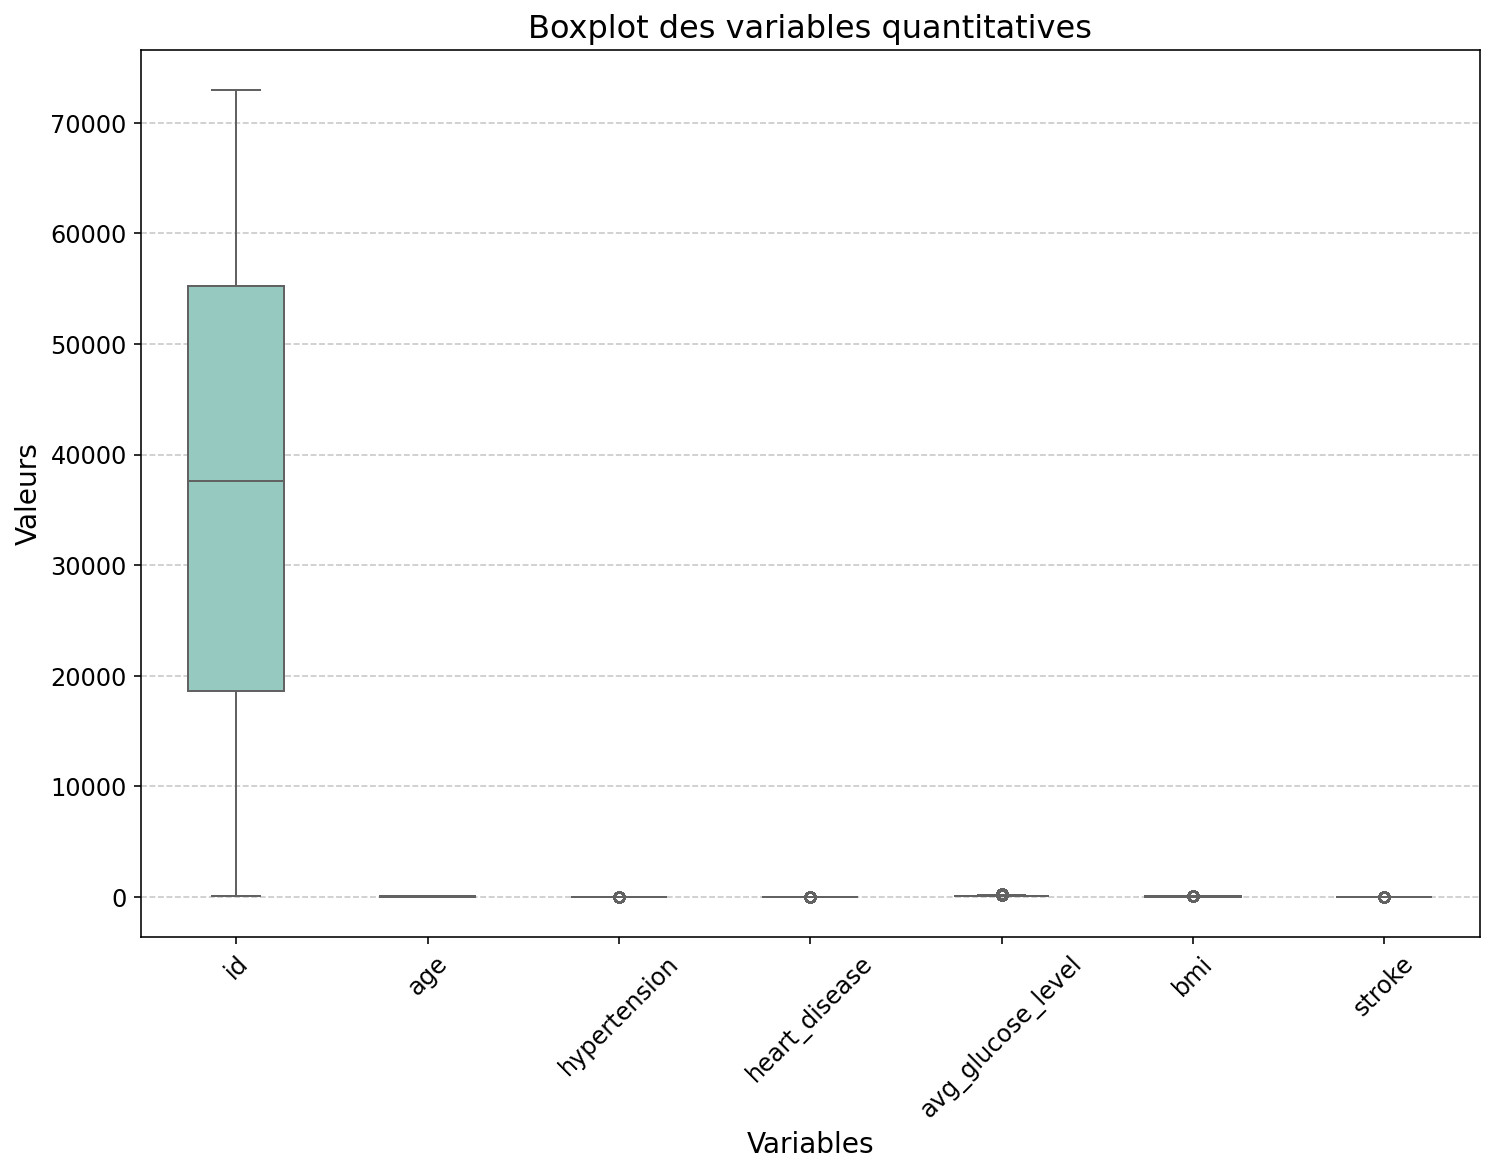

# III -          Modélisation

### Decision TreeClassifie

-           creation d'un classifieur d’arbre de décision avec les hyperparamètres